In [ ]:
import pandas as pd
df = pd.read_csv("/content/netflix.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB



Identify and analyze missing values in the dataset.


In [ ]:
df['director'].fillna('Not Specified', inplace=True)
df['cast'].fillna('Not Specified', inplace=True)
df['country'].fillna('Not Specified', inplace=True)
df['date_added'].fillna('Not Specified', inplace=True)
df['rating'].fillna('Not Specified', inplace=True)
df['duration'].fillna('Not Specified', inplace=True)

missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})
missing_info = missing_info.sort_values(by='Missing Percentage', ascending=False)
print(missing_info)

              Missing Count  Missing Percentage
show_id                   0                 0.0
type                      0                 0.0
title                     0                 0.0
director                  0                 0.0
cast                      0                 0.0
country                   0                 0.0
date_added                0                 0.0
release_year              0                 0.0
rating                    0                 0.0
duration                  0                 0.0
listed_in                 0                 0.0
description               0                 0.0


/tmp/ipython-input-182514939.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Not Specified', inplace=True)
/tmp/ipython-input-182514939.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
print(df['release_year'].describe())

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64



Review the categorical attributes 'type' and 'rating' by examining their unique values and their frequency distribution.


In [ ]:
print(df['type'].value_counts())


type
Movie      6131
TV Show    2676
Name: count, dtype: int64


In [ ]:
print(df['rating'].value_counts())

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


In [ ]:
df_countries = df.copy()
df_countries['country'] = df_countries['country'].fillna('Unknown')
df_countries['country'] = df_countries['country'].apply(lambda x: [s.strip() for s in x.split(',')])
df_countries = df_countries.explode('country')
print("Frequency distribution for 'country' (after handling multiple values and missing values):")
print(df_countries['country'].value_counts().head(10))

Frequency distribution for 'country' (after handling multiple values and missing values):
country
United States     3690
India             1046
Unknown            831
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


In [ ]:
df_genres = df.copy()
df_genres['listed_in'] = df_genres['listed_in'].apply(lambda x: [s.strip() for s in x.split(',')])
df_genres = df_genres.explode('listed_in')
print("Frequency distribution for 'listed_in' (after handling multiple values):")
print(df_genres['listed_in'].value_counts().head(10))

Frequency distribution for 'listed_in' (after handling multiple values):
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [ ]:
df['type'] = df['type'].astype('category')
df['rating'] = df['rating'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   show_id       8807 non-null   object  
 1   type          8807 non-null   category
 2   title         8807 non-null   object  
 3   director      8807 non-null   object  
 4   cast          8807 non-null   object  
 5   country       8807 non-null   object  
 6   date_added    8807 non-null   object  
 7   release_year  8807 non-null   int64   
 8   rating        8807 non-null   category
 9   duration      8807 non-null   object  
 10  listed_in     8807 non-null   object  
 11  description   8807 non-null   object  
dtypes: category(2), int64(1), object(9)
memory usage: 706.2+ KB


In [ ]:
# Check for duplicated rows
duplicated_rows = df.duplicated().sum()

print(f"Number of duplicated rows: {duplicated_rows}")

# If there are duplicated rows, show the first 5 of them
if duplicated_rows > 0:
    print("\nFirst 5 duplicated rows (if any):")
    print(df[df.duplicated(keep=False)].head()) # keep=False shows all duplicates

Number of duplicated rows: 0


In [ ]:

print("\nNumber of unique countries:", df_countries['country'].nunique())
print("Frequency distribution for 'country' (top 10):\n", df_countries['country'].value_counts().head(10))

print("\nNumber of unique genres:", df_genres['listed_in'].nunique())
print("Frequency distribution for 'listed_in' (top 10):\n", df_genres['listed_in'].value_counts().head(10))


Number of unique countries: 124
Frequency distribution for 'country' (top 10):
 country
United States     3690
India             1046
Unknown            831
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

Number of unique genres: 42
Frequency distribution for 'listed_in' (top 10):
 listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


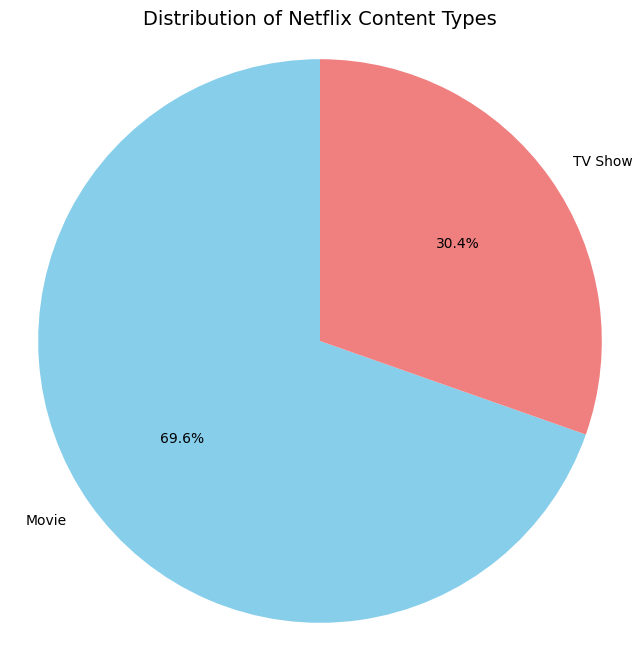

Pie chart showing the overall distribution of movies and TV shows has been generated.


In [ ]:
import matplotlib.pyplot as plt

type_counts = df['type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Distribution of Netflix Content Types', fontsize=14)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

print("Pie chart showing the overall distribution of movies and TV shows has been generated.")

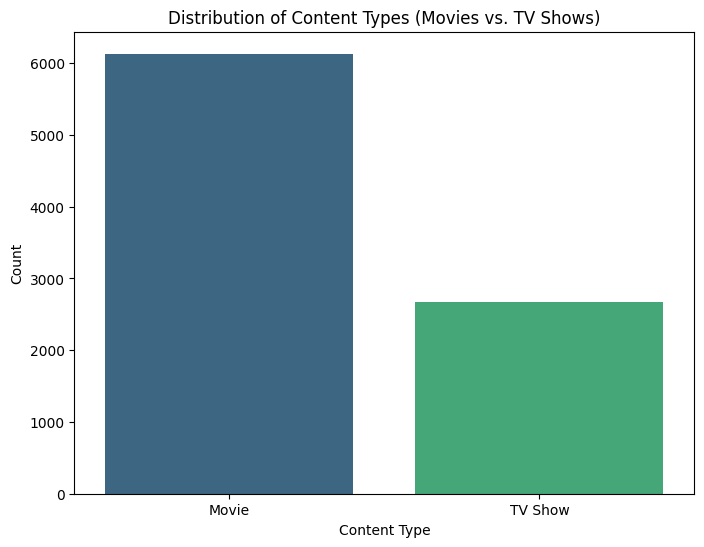

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.countplot(x='type', data=df, palette='viridis', hue='type', legend=False)
plt.title('Distribution of Content Types (Movies vs. TV Shows)')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

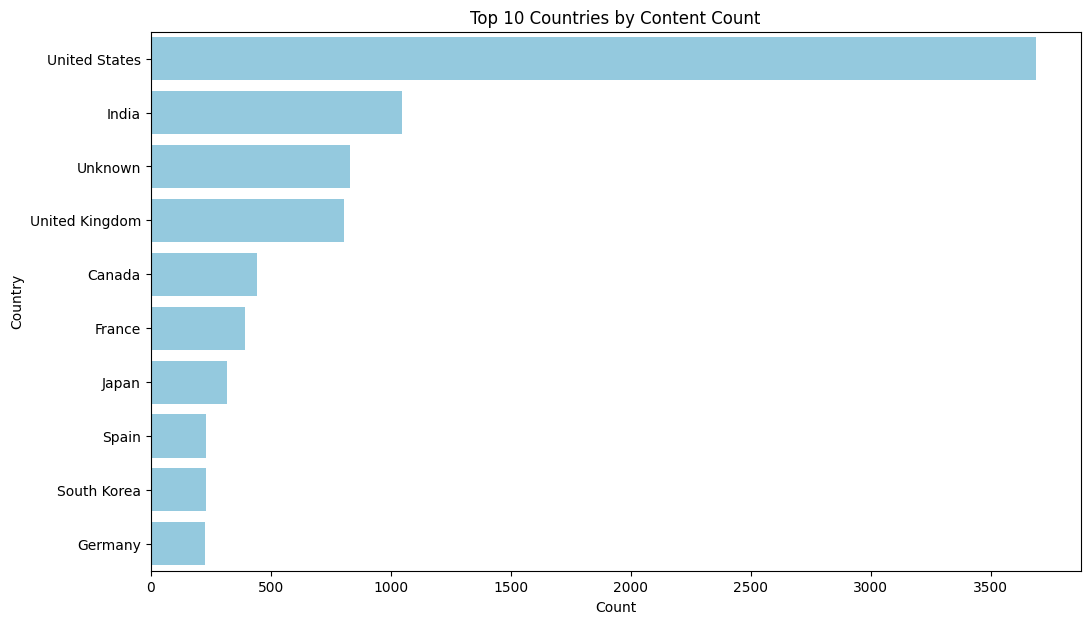

In [ ]:
top_countries_counts = df_countries['country'].value_counts().head(10)
plt.figure(figsize=(12, 7))
sns.barplot(x=top_countries_counts.values, y=top_countries_counts.index, color='skyblue', legend=False)
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

<Figure size 1400x800 with 0 Axes>

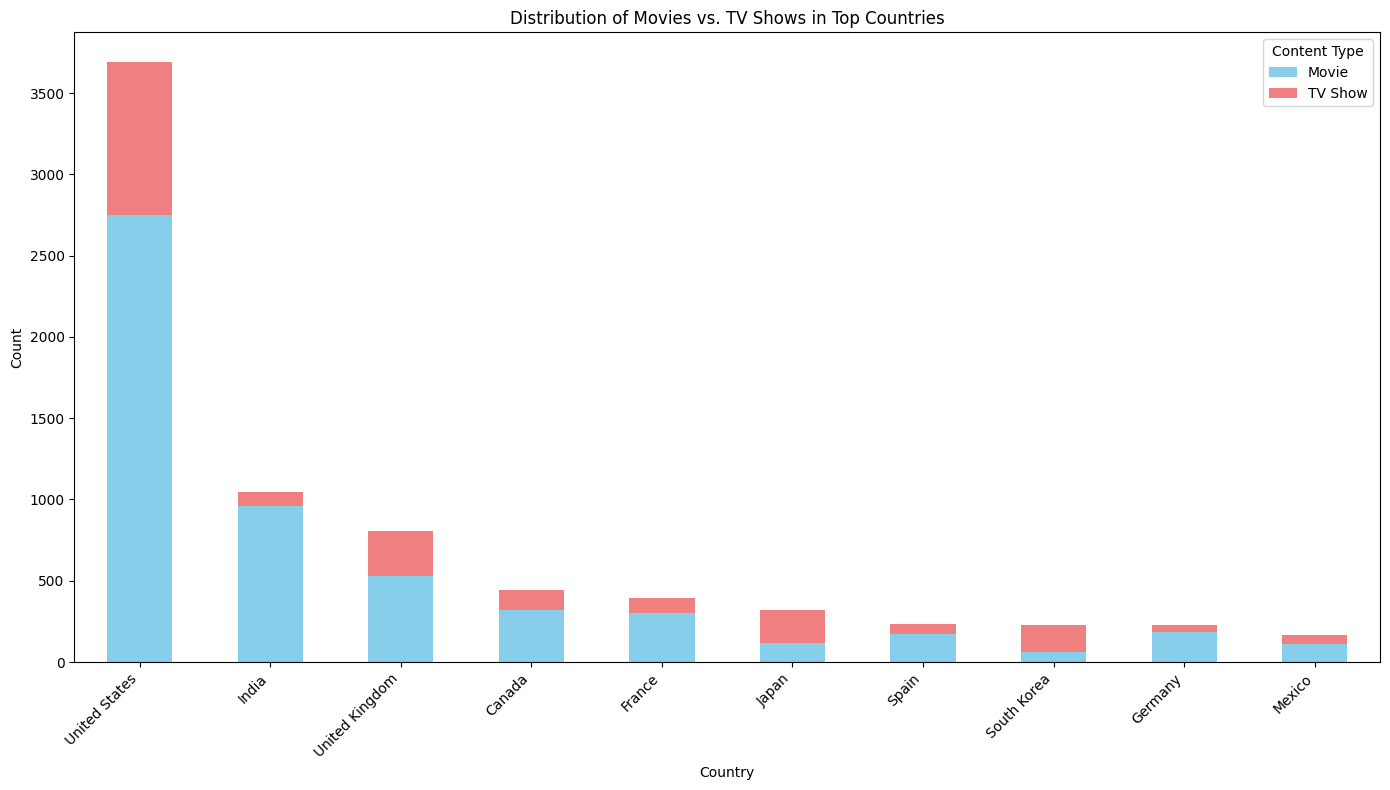

In [ ]:
plt.figure(figsize=(14, 8))
pivoted_df.plot(kind='bar', stacked=True, figsize=(14, 8), color=['skyblue', 'lightcoral'])
plt.title('Distribution of Movies vs. TV Shows in Top Countries')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

### Insights for type of content in different countries

**1. Overall Distribution and Range of Attributes:**
*   **Type**: The dataset primarily consists of two content types: 'Movie' and 'TV Show'. Analysis showed a significant dominance of Movies (6131 entries) over TV Shows (2676 entries). This was visually confirmed by the content type distribution countplot.
*   **Rating**: The 'rating' column displays a wide range of content classifications, with 'TV-MA', 'TV-14', and 'TV-PG' being the most frequent. The unique values also revealed some entries that appeared to be 'duration' values ('74 min', '84 min', '66 min') which suggests a potential data entry error or inconsistency that was addressed by filling missing values with 'Not Specified'.
*   **Country**: The 'country' column, after unnesting, revealed a highly diverse global content library, with 124 unique countries represented. Non-graphical analysis showed the 'United States', 'India', 'United Kingdom', 'Canada', and 'France' as the top contributors. The 'Unknown' category also ranked high, indicating a significant number of entries with unspecified country information.
*   **Genres**: There are 42 unique genres listed. 'International Movies', 'Dramas', and 'Comedies' are the most prevalent genres, highlighting the broad appeal and variety of content available.

**2. Primary Content Type on Netflix:**
Netflix's content library is predominantly composed of **Movies**. Both the non-graphical `value_counts()` for 'type' and the corresponding countplot clearly illustrate that there are more than twice as many movies as TV shows on the platform.

**3. Countries Producing the Most Content:**
*   The **United States** is by far the largest contributor, followed by **India**. The 'Unknown' category, which we filled, also represents a substantial portion, suggesting that country information is not always available or was not standardized. The top 10 countries are dominated by North American, European, and Asian nations, with the US having significantly more content than any other single country.

**4. Distribution of Movies vs. TV Shows Across Top Countries:**
*   The stacked bar chart for content types in top countries reveals interesting patterns:
    *   **United States**: Shows a strong preference for Movies, but also has a substantial number of TV Shows, indicating a balanced production capacity for both types.
    *   **India**: Heavily skewed towards Movies, with a comparatively small number of TV Shows.
    *   **United Kingdom**: Also shows a higher count for Movies, but with a notable proportion of TV Shows, more balanced than India.
    *   **Japan and South Korea**: Stand out with a higher proportion of TV Shows relative to Movies compared to other top countries like India or the US, especially for Japan which has more TV Shows than Movies in its top content list, and South Korea which has almost as many TV Shows as Movies.


In [ ]:
movies_df = df[df['type'] == 'Movie']

print("Value counts for 'type' in movies_df:")
print(movies_df['type'].value_counts())

print("\nValue counts for 'release_year' in movies_df:")
print(movies_df['release_year'].value_counts().sort_index())

print("\nUnique values in 'release_year' for movies_df:")
print(movies_df['release_year'].unique())

Value counts for 'type' in movies_df:
type
Movie      6131
TV Show       0
Name: count, dtype: int64

Value counts for 'release_year' in movies_df:
release_year
1942      2
1943      3
1944      3
1945      3
1946      1
       ... 
2017    767
2018    767
2019    633
2020    517
2021    277
Name: count, Length: 73, dtype: int64

Unique values in 'release_year' for movies_df:
[2020 2021 1993 1996 1998 1997 2010 2013 2017 1975 1978 1983 1987 2012
 2001 2002 2003 2004 2011 2008 2009 2007 2005 2006 2018 2019 1994 2015
 1982 1989 2014 1990 1991 1999 2016 1986 1984 1980 1961 2000 1995 1985
 1992 1976 1959 1988 1981 1972 1964 1954 1979 1958 1956 1963 1970 1973
 1960 1974 1966 1971 1962 1969 1977 1967 1968 1965 1945 1946 1942 1955
 1944 1947 1943]


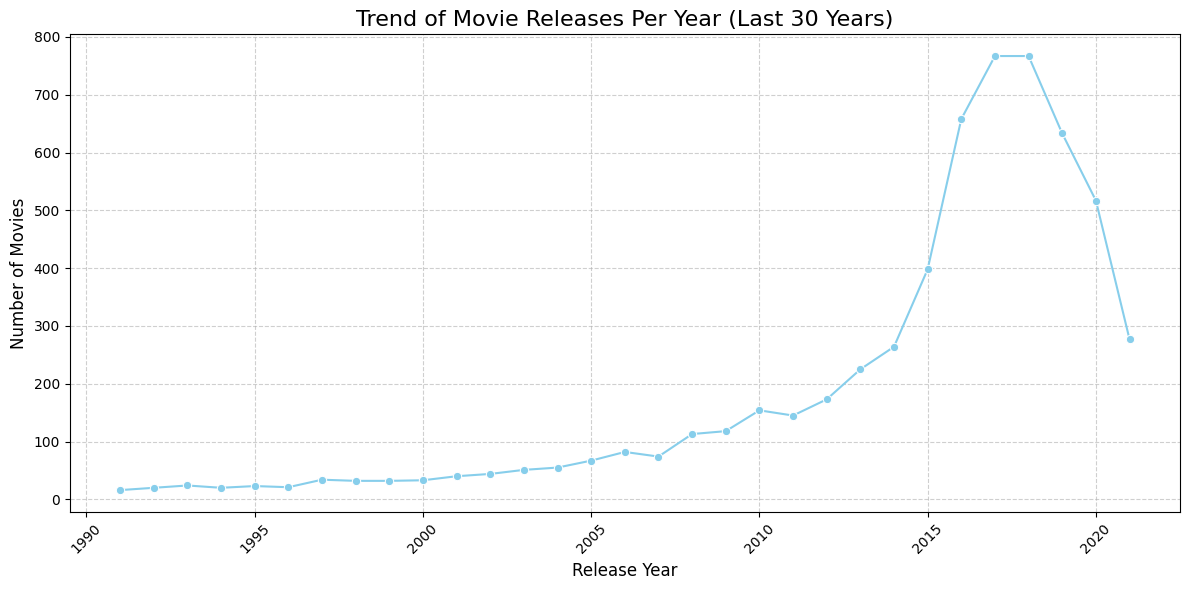

Line plot showing the trend of movie releases per year over the last 30 years has been generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of movies released per year
movies_per_year = movies_df['release_year'].value_counts().sort_index().reset_index()
movies_per_year.columns = ['release_year', 'count']

# Filter for the last 30 years (from 2021 back to 1991)
current_year = 2021 # Assuming the data is up to 2021
min_release_year = current_year - 30
movies_per_year_recent = movies_per_year[movies_per_year['release_year'] >= min_release_year]

# Plot the trend
plt.figure(figsize=(12, 6))
sns.lineplot(x='release_year', y='count', data=movies_per_year_recent, marker='o', color='skyblue')
plt.title('Trend of Movie Releases Per Year (Last 30 Years)', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Line plot showing the trend of movie releases per year over the last 30 years has been generated.")

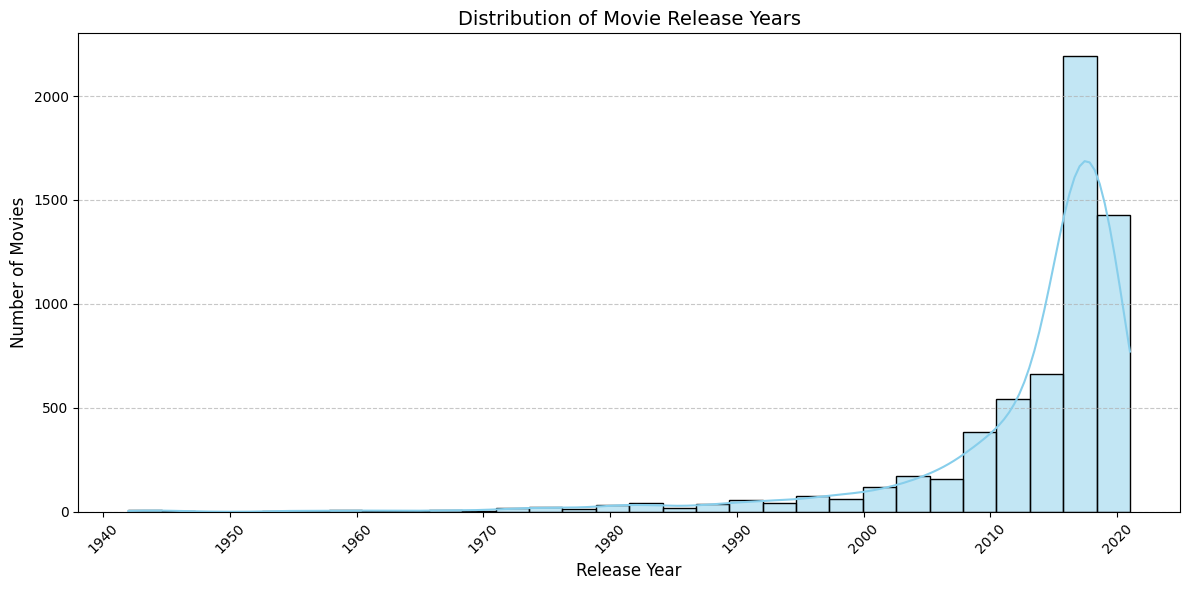

Histogram showing the distribution of movie release years has been generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(movies_df['release_year'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Movie Release Years', fontsize=14)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Histogram showing the distribution of movie release years has been generated.")

In [ ]:
movies_df.loc[:, 'movie_duration_minutes'] = movies_df['duration'].apply(lambda x: int(x.split(' ')[0]) if 'min' in x else None)
print("Cleaned 'duration' column and created 'movie_duration_minutes' in movies_df.")
print(movies_df[['duration', 'movie_duration_minutes']].head())

Cleaned 'duration' column and created 'movie_duration_minutes' in movies_df.
   duration  movie_duration_minutes
0    90 min                    90.0
6    91 min                    91.0
7   125 min                   125.0
9   104 min                   104.0
12  127 min                   127.0


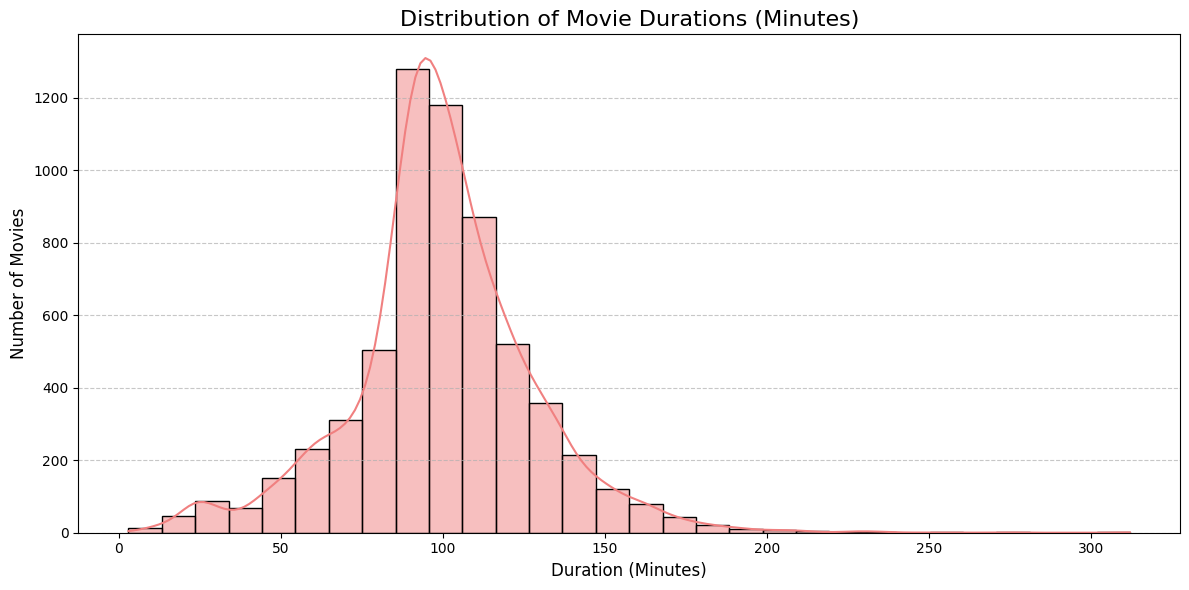

Histogram showing the distribution of movie durations has been generated.


In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(movies_df['movie_duration_minutes'].dropna(), bins=30, kde=True, color='lightcoral')
plt.title('Distribution of Movie Durations (Minutes)', fontsize=16)
plt.xlabel('Duration (Minutes)', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Histogram showing the distribution of movie durations has been generated.")

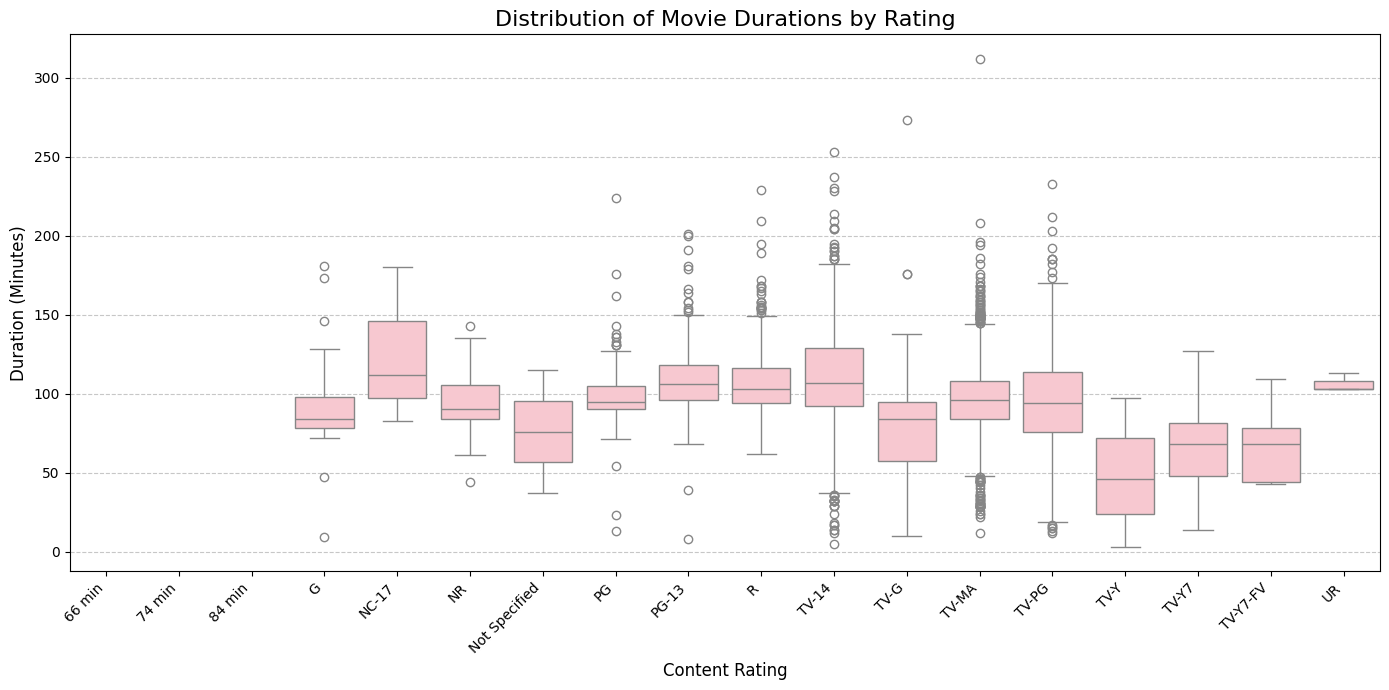

Box plot showing the distribution of movie durations across ratings has been generated.


In [ ]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='rating', y='movie_duration_minutes', data=movies_df.dropna(subset=['movie_duration_minutes', 'rating']), color = 'pink')
plt.title('Distribution of Movie Durations by Rating', fontsize=16)
plt.xlabel('Content Rating', fontsize=12)
plt.ylabel('Duration (Minutes)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Box plot showing the distribution of movie durations across ratings has been generated.")

### Insights for Movie trends

**1. Trend of Movie Releases Per Year (Last 30 Years):**
*   The line plot of movie releases per year (1991-2021) shows a clear upward trend, indicating a significant increase in movie production and acquisition by Netflix over the decades. There's a notable surge in releases starting from the mid-2000s, peaking around 2017-2018. This suggests a period of aggressive content expansion by the platform.
*   There's a slight dip in 2019, followed by a more pronounced decrease in 2020 and 2021. This could be attributed to various factors, including the COVID-19 pandemic impacting production schedules, or a shift in content strategy towards quality over quantity, or a combination of both.

**2. Distribution of Movie Release Years:**
*   The histogram of movie release years confirms the observations from the line plot. It shows a concentrated distribution of movies released in more recent years, with a heavy skew towards the 21st century. The peak aligns with the mid to late 2010s.

**3. Distribution of Movie Durations (Minutes):**
*   The histogram for movie_duration_minutes reveals that the majority of movies on Netflix fall within a typical feature film length, with a prominent peak between approximately 80 and 120 minutes. The distribution is somewhat bell-shaped, with fewer very short or very long movies.
*   This suggests that Netflix's movie library caters to standard viewing habits, providing content that can be consumed within a typical sitting.

**4. Distribution of Movie Durations by Rating:**
*   The box plot shows the distribution of movie durations across different content ratings.
*   **Children's Content (G, TV-Y, TV-Y7, TV-G):** Generally has shorter durations, often with narrower interquartile ranges, indicating more consistent and shorter runtimes suitable for younger audiences. For instance, TV-Y and G-rated movies tend to be on the shorter side.
*   **Teen and General Audiences (PG, PG-13, TV-PG, TV-14):** Shows a moderate increase in duration, with a wider spread of lengths, reflecting a broader range of cinematic experiences aimed at these demographics.
*   **Mature Audiences (R, TV-MA, NC-17):** These categories tend to have the longest durations on average, and often exhibit a wider spread, with some outliers indicating very long films. This is consistent with more complex narratives that often require longer runtimes.

Overall, these visualizations provide a comprehensive view of movie trends on Netflix, highlighting growth patterns, typical movie lengths, and how duration correlates with content rating.

In [ ]:
Q1_movie_duration = movies_df['movie_duration_minutes'].quantile(0.25)
Q3_movie_duration = movies_df['movie_duration_minutes'].quantile(0.75)
IQR_movie_duration = Q3_movie_duration - Q1_movie_duration

print(f"Q1 for Movie Duration: {Q1_movie_duration}")
print(f"Q3 for Movie Duration: {Q3_movie_duration}")
print(f"IQR for Movie Duration: {IQR_movie_duration}")

Q1 for Movie Duration: 87.0
Q3 for Movie Duration: 114.0
IQR for Movie Duration: 27.0


In [ ]:
lower_bound_movie_duration = Q1_movie_duration - 1.5 * IQR_movie_duration
upper_bound_movie_duration = Q3_movie_duration + 1.5 * IQR_movie_duration

print(f"Lower Bound for Movie Duration Outliers: {lower_bound_movie_duration}")
print(f"Upper Bound for Movie Duration Outliers: {upper_bound_movie_duration}")

Lower Bound for Movie Duration Outliers: 46.5
Upper Bound for Movie Duration Outliers: 154.5


In [ ]:
outliers_movie_duration = movies_df[(movies_df['movie_duration_minutes'] < lower_bound_movie_duration) | (movies_df['movie_duration_minutes'] > upper_bound_movie_duration)]

print("Movies identified as outliers based on 'movie_duration_minutes':")
print(outliers_movie_duration[['title', 'movie_duration_minutes']])

Movies identified as outliers based on 'movie_duration_minutes':
                                title  movie_duration_minutes
22                    Avvai Shanmughi                   161.0
24                              Jeans                   166.0
45             My Heroes Were Cowboys                    23.0
71        A StoryBots Space Adventure                    13.0
73                       King of Boys                   182.0
...                               ...                     ...
8763  WWII: Report from the Aleutians                    45.0
8764                       Wyatt Earp                   191.0
8770                          Yaadein                   171.0
8788                     You Carry Me                   157.0
8802                           Zodiac                   158.0

[450 rows x 2 columns]



The number of TV shows released per year on Netflix shows a consistent and accelerating upward trend, particularly from the mid-2010s onwards, peaking in 2020 with 436 releases. This contrasts with the movie release trend, which showed a decline post-2018.

*   The tv_shows_df contains 2676 entries, spanning release years from 1925 to 2021.
*   TV show releases have experienced significant growth over the last 30 years, with a sharp increase observed from the mid-2000s, reaching its peak in 2020 (436 releases). A high number of releases was also observed in 2021 (315 releases), indicating sustained investment.
*   The trend for TV shows diverges significantly from that of movies; while movie releases declined post-2018, TV show releases continued their upward trajectory.

### Insights
*   Netflix's strategy appears to involve a strong and increasing focus on TV shows, likely driven by their effectiveness in subscriber retention, appeal to the binge-watching culture, and global success potential. This represents a strategic rebalancing of content investment away from sheer movie volume.



Analyze the 'duration' column for both movies (in minutes) and TV shows (in seasons).


In [ ]:
tv_shows_df.loc[:, 'num_seasons'] = tv_shows_df['duration'].apply(lambda x: int(x.split(' ')[0]) if 'Season' in x else None)
print("Cleaned 'duration' column and created 'num_seasons' in tv_shows_df.")
print(tv_shows_df[['duration', 'num_seasons']].head())

Cleaned 'duration' column and created 'num_seasons' in tv_shows_df.
    duration  num_seasons
1  2 Seasons            2
2   1 Season            1
3   1 Season            1
4  2 Seasons            2
5   1 Season            1


/tmp/ipython-input-1169920427.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tv_shows_df.loc[:, 'num_seasons'] = tv_shows_df['duration'].apply(lambda x: int(x.split(' ')[0]) if 'Season' in x else None)


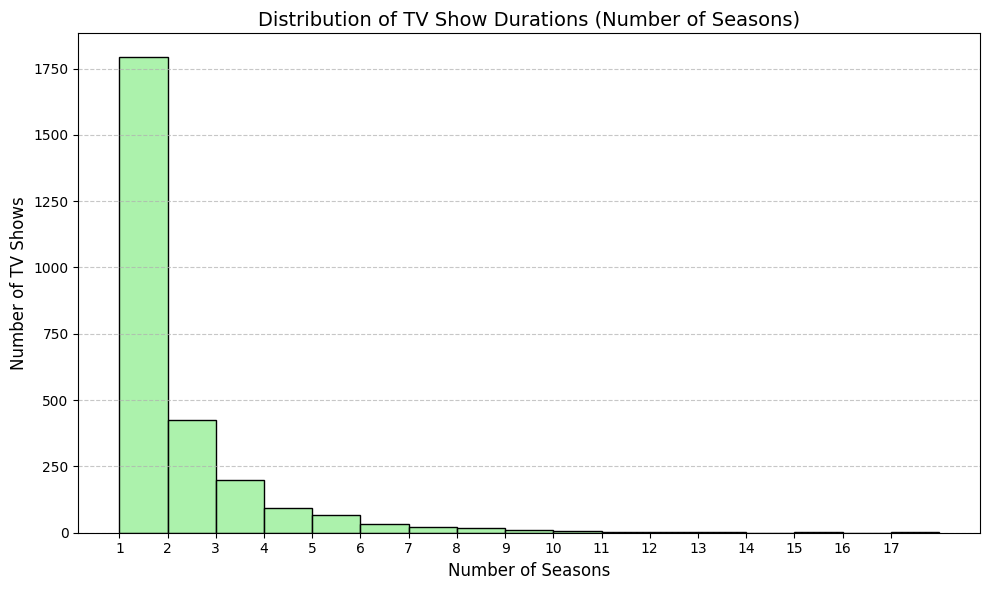

Histogram showing the distribution of TV show durations (number of seasons) has been generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(tv_shows_df['num_seasons'].dropna(), bins=range(1, int(tv_shows_df['num_seasons'].max()) + 2), kde=False, color='lightgreen')
plt.title('Distribution of TV Show Durations (Number of Seasons)', fontsize=14)
plt.xlabel('Number of Seasons', fontsize=12)
plt.ylabel('Number of TV Shows', fontsize=12)
plt.xticks(range(1, int(tv_shows_df['num_seasons'].max()) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Histogram showing the distribution of TV show durations (number of seasons) has been generated.")

### Summary: Compare Content Duration

Movies on Netflix primarily have durations ranging from 80 to 120 minutes, while the vast majority of TV shows consist of 1 or 2 seasons. There are outliers for both content types, with some movies being very short or very long, and some TV shows having many more seasons.

*   **Movie Durations**: The distribution of movie durations is concentrated between approximately 80 and 120 minutes, with a mean duration of around 99 minutes. This suggests that Netflix's movie library largely caters to standard feature film lengths. Movies rated for children (G, TV-Y, TV-G) tend to be shorter, while mature content (R, TV-MA) often has longer durations.
*   **TV Show Durations**: The distribution of TV show durations, measured in seasons, is heavily skewed towards shorter series. A significant majority of TV shows on Netflix have only 1 season (approximately 1793 shows), followed by 2 seasons (approximately 674 shows). Shows with 3, 4, or more seasons are less common but represent valuable long-form content.
*   **Outliers**:
    *   For movies, outliers were identified for very short films (less than 46.5 minutes) and very long films (greater than 154.5 minutes), indicating a diverse range of cinematic lengths beyond the typical. There are 450 such outliers.
    *   For TV shows, series with more than 3 seasons (i.e., 4 seasons and above) are considered outliers based on the 1.5 * IQR rule (upper bound 3.5 seasons). There are 259 such outliers, including shows with up to 17 seasons.

**Insights**
*   Netflix's content strategy provides a mix of content lengths: typically short-to-medium length movies and predominantly short-run TV series. The prevalence of 1-season TV shows could indicate a strategy of testing new concepts or catering to viewers who prefer shorter commitments.
*   The presence of longer TV series (outliers) and longer movies indicates a commitment to diverse storytelling formats, which can cater to different audience segments and viewing habits (e.g., binge-watching longer series, or enjoying epic films).



Identify and compare the most popular genres ('listed_in') for both movies and TV shows.


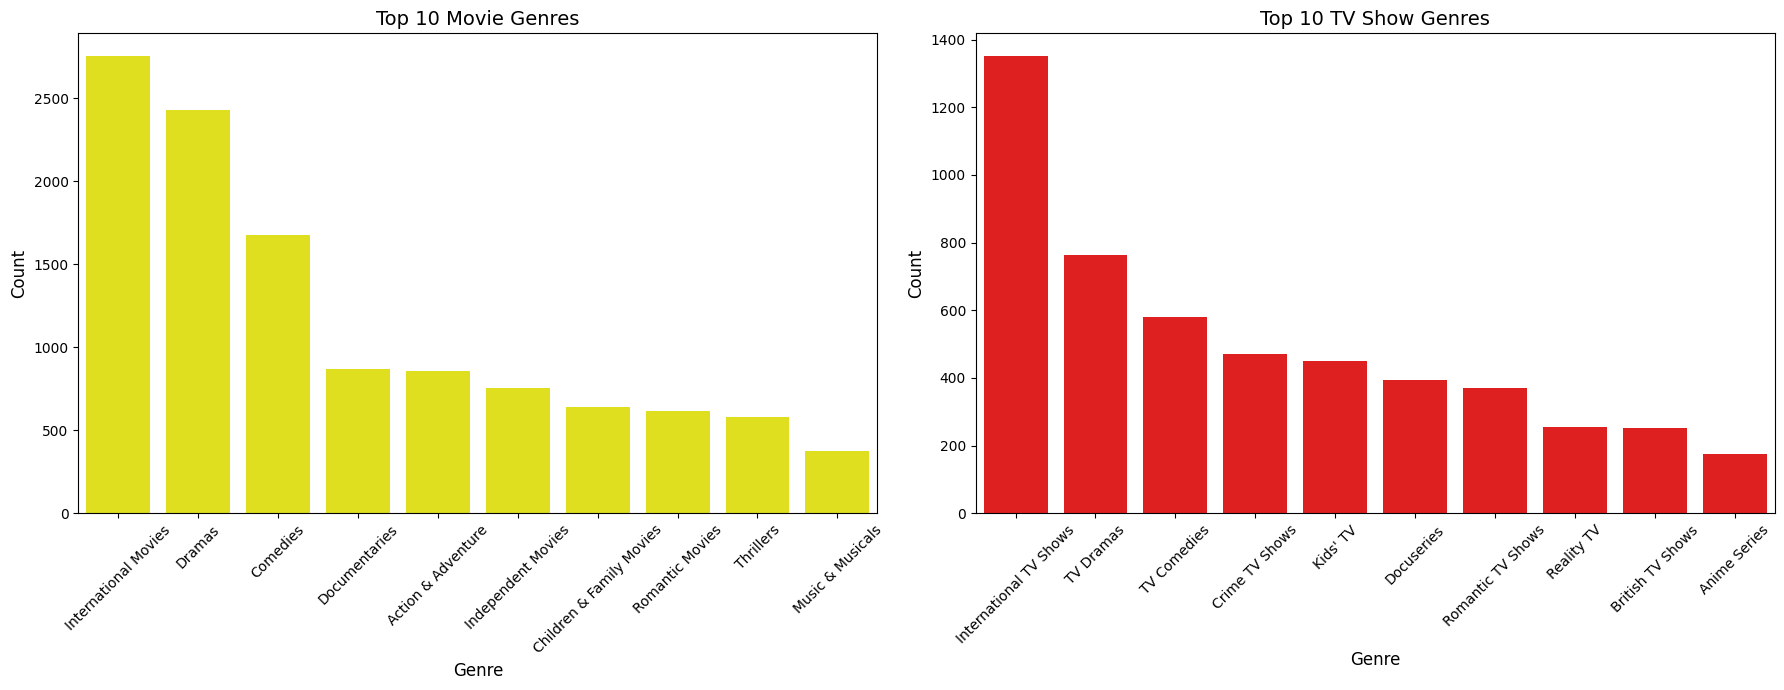

Two bar plots showing the top 10 genres for movies and TV shows have been generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter df_genres for 'Movie' entries
df_movie_genres = df_genres[df_genres['type'] == 'Movie']

# 2. Filter df_genres for 'TV Show' entries
df_tv_show_genres = df_genres[df_genres['type'] == 'TV Show']

# 3. Calculate the top 10 movie genres
top_movie_genres = df_movie_genres['listed_in'].value_counts().head(10)

# 4. Calculate the top 10 TV show genres
top_tv_show_genres = df_tv_show_genres['listed_in'].value_counts().head(10)

# 5. Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 6. Bar plot for Top 10 Movie Genres
sns.barplot(x=top_movie_genres.index, y=top_movie_genres.values, ax=axes[0], color='yellow', legend=False)
axes[0].set_title('Top 10 Movie Genres', fontsize=14)
axes[0].set_xlabel('Genre', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# 7. Bar plot for Top 10 TV Show Genres
sns.barplot(x=top_tv_show_genres.index, y=top_tv_show_genres.values, ax=axes[1], color='red', legend=False)
axes[1].set_title('Top 10 TV Show Genres', fontsize=14)
axes[1].set_xlabel('Genre', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# 8. Adjust layout and display the plot
plt.tight_layout()
plt.show()

print("Two bar plots showing the top 10 genres for movies and TV shows have been generated.")

### Summary: Compare Top Genres

*   **Movie Genres**: The top movie genres highlight a strong global and diverse appeal. 'International Movies' is by far the most frequent genre (2752 entries), followed by 'Dramas' (2427) and 'Comedies' (1674). Other significant movie genres include 'Documentaries', 'Action & Adventure', and 'Independent Movies'.
*   **TV Show Genres**: For TV shows, 'International TV Shows' leads significantly (1351 entries), indicating Netflix's success in global serialized content. This is followed by 'TV Dramas' (763) and 'TV Comedies' (581). 'Crime TV Shows', 'Kids' TV', and 'Docuseries' also feature prominently in the top TV show genres.
*   **Overlap and Differences**: There's an expected overlap in general categories like 'Dramas' and 'Comedies' for both content types. However, movies tend to have broader categories like 'International Movies' and 'Independent Movies', while TV shows feature more specific, serialized categories like 'International TV Shows', 'Kids' TV', 'Docuseries', and 'Anime Series'. This reflects the different formats and storytelling approaches of movies versus TV shows.

 ### Insights
*   Netflix's strategy effectively caters to a global audience for both movies and TV shows, with 'International' categories being dominant for both formats. This suggests successful localization and acquisition efforts.
*   The strong presence of 'Dramas' and 'Comedies' across both content types indicates these are universally popular genres that Netflix should continue to invest in.
*   The specific popularity of 'Kids' TV' and 'Anime Series' within TV shows highlights niche but potentially very loyal audience segments that Netflix is successfully serving.
*   Further analysis could involve cross-referencing top genres with country of origin and release year to understand how genre popularity evolves geographically and over time, informing more granular content strategy.

 'Which month sees the most TV show additions across all years, suggesting potential periods of higher audience engagement?'


In [ ]:
tv_shows_monthly_df = df[df['type'] == 'TV Show'].copy()

# Convert 'date_added' to datetime, coercing errors to NaT
tv_shows_monthly_df['date_added'] = pd.to_datetime(tv_shows_monthly_df['date_added'], errors='coerce')

# Extract month name, excluding NaT values
tv_shows_monthly_df['month_added'] = tv_shows_monthly_df['date_added'].dt.month_name()

print("Filtered DataFrame 'tv_shows_monthly_df' created.")
print("Converted 'date_added' to datetime and extracted 'month_added'.")
print(tv_shows_monthly_df[['date_added', 'month_added']].head())

Filtered DataFrame 'tv_shows_monthly_df' created.
Converted 'date_added' to datetime and extracted 'month_added'.
  date_added month_added
1 2021-09-24   September
2 2021-09-24   September
3 2021-09-24   September
4 2021-09-24   September
5 2021-09-24   September


In [ ]:
tv_show_additions_by_month = tv_shows_monthly_df['month_added'].value_counts()

# Ensure all 12 months are present, even if some have 0 additions
all_months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
tv_show_additions_by_month = tv_show_additions_by_month.reindex(all_months, fill_value=0)

print("Number of TV show additions by month:")
print(tv_show_additions_by_month)

most_popular_month = tv_show_additions_by_month.idxmax()
max_additions = tv_show_additions_by_month.max()

print(f"\nThe month with the most TV show additions is {most_popular_month} with {max_additions} additions.")

Number of TV show additions by month:
month_added
January      181
February     175
March        205
April        209
May          187
June         232
July         254
August       230
September    246
October      210
November     199
December     250
Name: count, dtype: int64

The month with the most TV show additions is July with 254 additions.


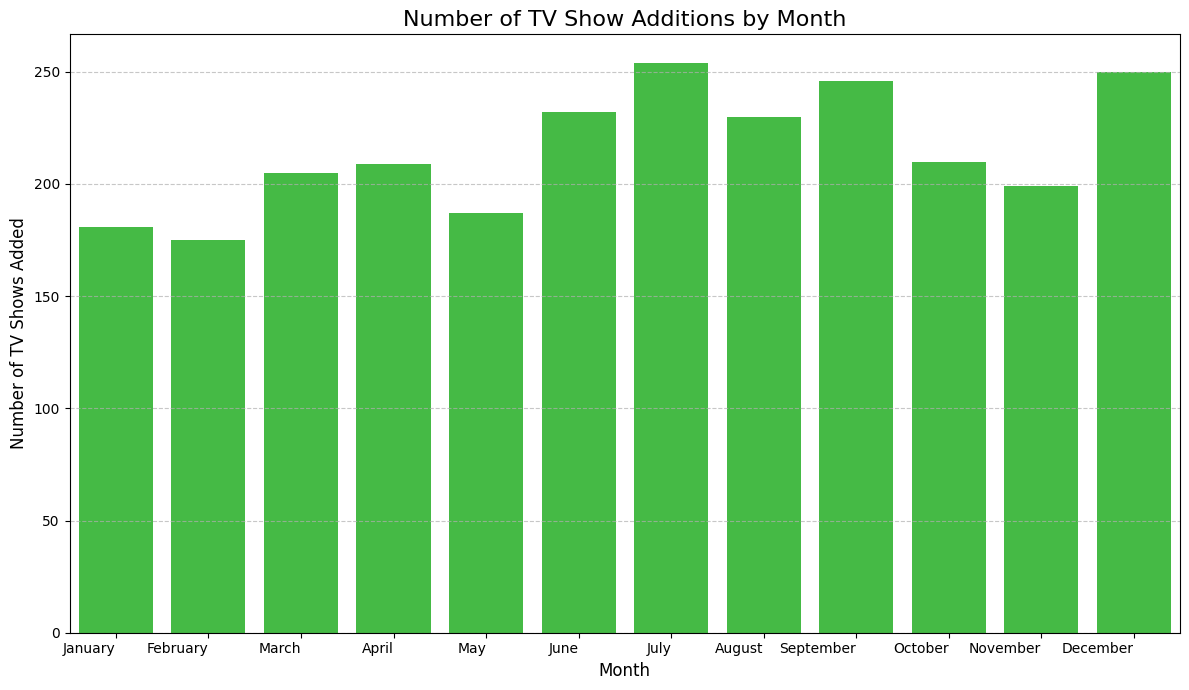

Bar plot showing the number of TV show additions by month has been generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=tv_show_additions_by_month.index, y=tv_show_additions_by_month.values, color = 'limegreen', legend=False)
plt.title('Number of TV Show Additions by Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of TV Shows Added', fontsize=12)
plt.xticks(rotation=0, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Bar plot showing the number of TV show additions by month has been generated.")

###**Insights**
July sees the most TV show additions across all years with 254 additions, followed closely by September (246 additions) and December (250 additions). This suggests these months are key periods for Netflix to release new TV show content.

*   The month with the highest number of TV show additions is July, with 254 TV shows added.
*   Other months with a high volume of TV show additions include December (250), September (246), and June (232).
*   The months with comparatively fewer TV show additions are February (175) and January (181).
*   Netflix appears to strategically release a significant portion of its TV show content in the summer months (July, June) and towards the end of the year (September, December). This could be to capture audiences during holiday seasons, summer breaks, or to build anticipation for year-end viewing.
*   Understanding these peak months can help Netflix in planning content marketing campaigns, scheduling new show launches, and optimizing promotional efforts to maximize audience engagement and subscriber growth.


Analysis of actors/directors of different types of shows/movies.

In [ ]:
df_actors = df.copy()
df_actors = df_actors[df_actors['cast'] != 'Not Specified']
df_actors.loc[:, 'cast'] = df_actors['cast'].apply(lambda x: [s.strip() for s in x.split(',')])
df_actors = df_actors.explode('cast')
df_actors = df_actors.rename(columns={'cast': 'actor'})

print("Created df_actors DataFrame with cleaned and exploded 'actor' column.")
print(df_actors[['type', 'actor']].head())

Created df_actors DataFrame with cleaned and exploded 'actor' column.
      type             actor
1  TV Show        Ama Qamata
1  TV Show       Khosi Ngema
1  TV Show     Gail Mabalane
1  TV Show    Thabang Molaba
1  TV Show  Dillon Windvogel


In [ ]:
df_directors = df.copy()
df_directors = df_directors[df_directors['director'] != 'Not Specified']
df_directors.loc[:, 'director'] = df_directors['director'].apply(lambda x: [s.strip() for s in x.split(',')])
df_directors = df_directors.explode('director')

print("Created df_directors DataFrame with cleaned and exploded 'director' column.")
print(df_directors[['type', 'director']].head())

Created df_directors DataFrame with cleaned and exploded 'director' column.
      type         director
0    Movie  Kirsten Johnson
2  TV Show  Julien Leclercq
5  TV Show    Mike Flanagan
6    Movie    Robert Cullen
6    Movie   José Luis Ucha


In [ ]:
top_movie_actors = df_actors[df_actors['type'] == 'Movie']['actor'].value_counts().head(10).reset_index()
top_movie_actors.columns = ['actor', 'count']

top_tv_show_actors = df_actors[df_actors['type'] == 'TV Show']['actor'].value_counts().head(10).reset_index()
top_tv_show_actors.columns = ['actor', 'count']

print("Top 10 Movie Actors:\n", top_movie_actors)
print("\nTop 10 TV Show Actors:\n", top_tv_show_actors)

Top 10 Movie Actors:
               actor  count
0       Anupam Kher     42
1    Shah Rukh Khan     35
2  Naseeruddin Shah     32
3      Akshay Kumar     30
4           Om Puri     30
5      Paresh Rawal     28
6     Julie Tejwani     28
7  Amitabh Bachchan     28
8       Boman Irani     27
9      Rupa Bhimani     27

Top 10 TV Show Actors:
                 actor  count
0    Takahiro Sakurai     25
1           Yuki Kaji     19
2           Ai Kayano     17
3         Daisuke Ono     17
4      Junichi Suwabe     17
5     Yuichi Nakamura     16
6    Yoshimasa Hosoya     15
7        Jun Fukuyama     15
8  David Attenborough     14
9        Vincent Tong     13


In [ ]:
top_movie_directors = df_directors[df_directors['type'] == 'Movie']['director'].value_counts().head(10).reset_index()
top_movie_directors.columns = ['director', 'count']

top_tv_show_directors = df_directors[df_directors['type'] == 'TV Show']['director'].value_counts().head(10).reset_index()
top_tv_show_directors.columns = ['director', 'count']

print("Top 10 Movie Directors:\n", top_movie_directors)
print("\nTop 10 TV Show Directors:\n", top_tv_show_directors)

Top 10 Movie Directors:
               director  count
0        Rajiv Chilaka     22
1            Jan Suter     21
2          Raúl Campos     19
3          Suhas Kadav     16
4         Marcus Raboy     15
5            Jay Karas     15
6  Cathy Garcia-Molina     13
7      Martin Scorsese     12
8      Youssef Chahine     12
9          Jay Chapman     12

Top 10 TV Show Directors:
               director  count
0            Ken Burns      3
1  Alastair Fothergill      3
2          Hsu Fu-chun      2
3          Stan Lathan      2
4       Iginio Straffi      2
5        Joe Berlinger      2
6          Lynn Novick      2
7      Rob Seidenglanz      2
8           Jung-ah Im      2
9          Shin Won-ho      2


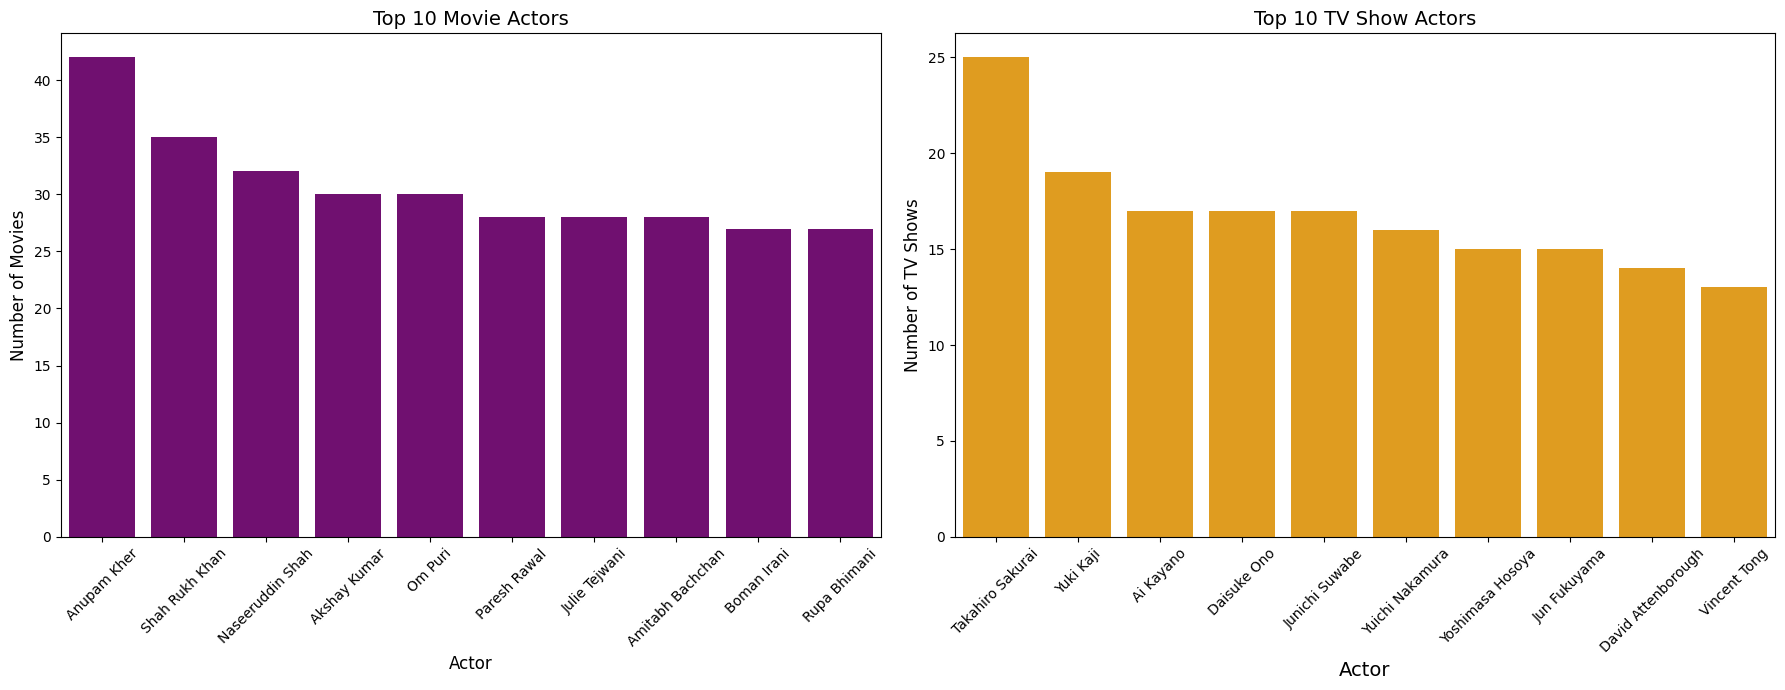

Two bar plots showing the top 10 actors for movies and TV shows have been generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots for actors
fig_actors, axes_actors = plt.subplots(1, 2, figsize=(18, 7))

# Bar plot for Top 10 Movie Actors
sns.barplot(x='actor', y='count', data=top_movie_actors, ax=axes_actors[0], color ='purple', legend=False)
axes_actors[0].set_title('Top 10 Movie Actors', fontsize=14)
axes_actors[0].set_xlabel('Actor', fontsize=12)
axes_actors[0].set_ylabel('Number of Movies', fontsize=12)
axes_actors[0].tick_params(axis='x', rotation=45)

# Bar plot for Top 10 TV Show Actors
sns.barplot(x='actor', y='count', data=top_tv_show_actors, ax=axes_actors[1], color='orange', legend=False)
axes_actors[1].set_title('Top 10 TV Show Actors', fontsize=14)
axes_actors[1].set_xlabel('Actor', fontsize=14)
axes_actors[1].set_ylabel('Number of TV Shows', fontsize=12)
axes_actors[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Two bar plots showing the top 10 actors for movies and TV shows have been generated.")

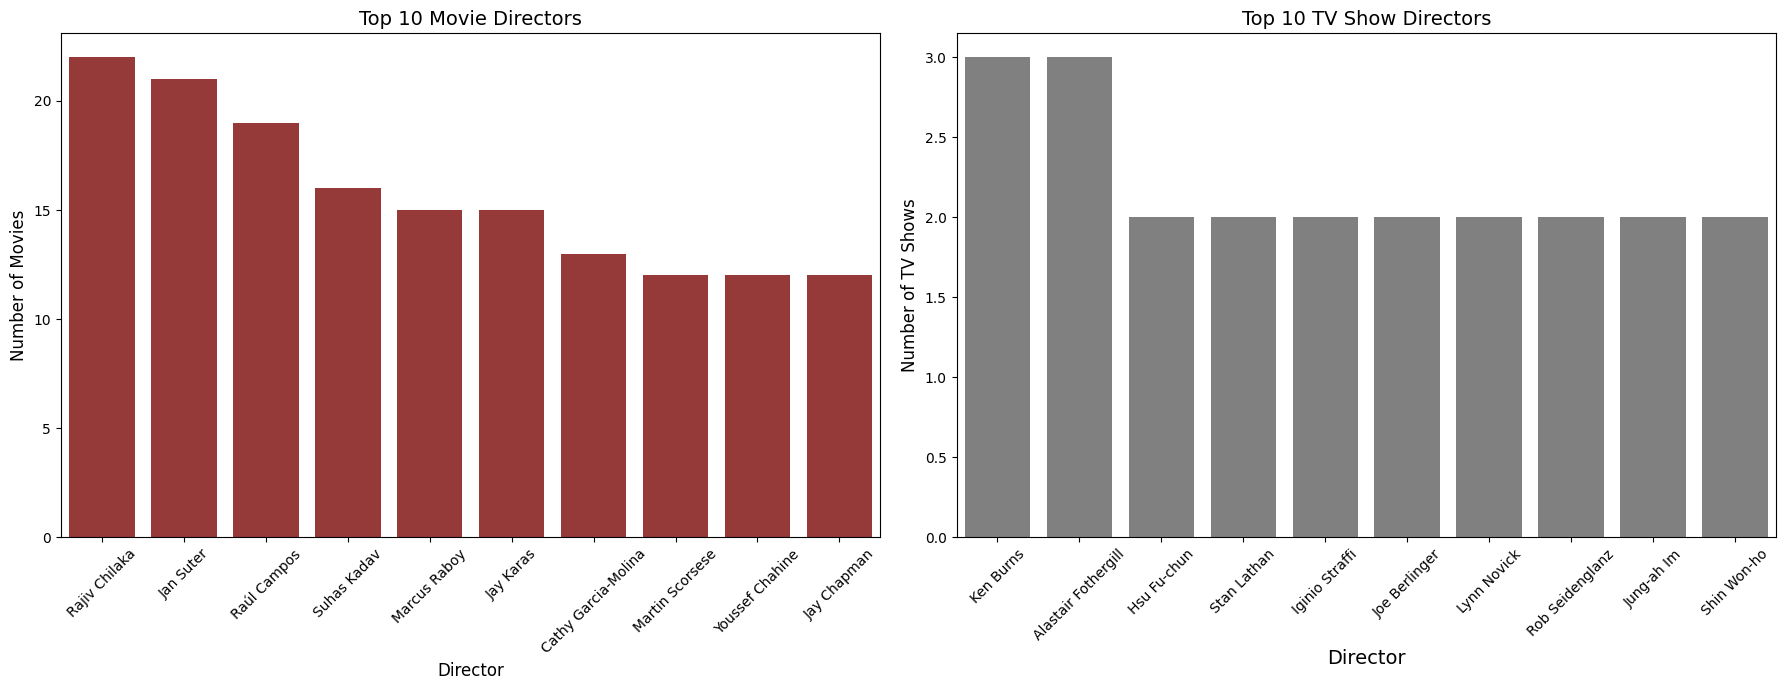

Two bar plots showing the top 10 directors for movies and TV shows have been generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots for directors
fig_directors, axes_directors = plt.subplots(1, 2, figsize=(18, 7))

# Bar plot for Top 10 Movie Directors
sns.barplot(x='director', y='count', data=top_movie_directors, ax=axes_directors[0], color='brown', legend=False)
axes_directors[0].set_title('Top 10 Movie Directors', fontsize=14)
axes_directors[0].set_xlabel('Director', fontsize=12)
axes_directors[0].set_ylabel('Number of Movies', fontsize=12)
axes_directors[0].tick_params(axis='x', rotation=45)

# Bar plot for Top 10 TV Show Directors
sns.barplot(x='director', y='count', data=top_tv_show_directors, ax=axes_directors[1], color='grey', legend=False)
axes_directors[1].set_title('Top 10 TV Show Directors', fontsize=14)
axes_directors[1].set_xlabel('Director', fontsize=14)
axes_directors[1].set_ylabel('Number of TV Shows', fontsize=12)
axes_directors[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Two bar plots showing the top 10 directors for movies and TV shows have been generated.")

### Summary: Top Actors and Directors

*   **Top Movie Actors**: The most prolific movie actors on Netflix primarily consist of Indian actors such as Anupam Kher, Shah Rukh Khan, Naseeruddin Shah, and Akshay Kumar. This strongly suggests a significant presence and continuous investment in the Indian film industry content.
*   **Top TV Show Actors**: For TV shows, the top actors are largely voice actors from Japan (e.g., Takahiro Sakurai, Yuki Kaji, Ai Kayano, Daisuke Ono, Junichi Suwabe), indicating a strong emphasis on and popularity of anime series on the platform. David Attenborough also features, reflecting Netflix's investment in nature documentaries.
*   **Top Movie Directors**: The top movie directors list includes a mix of international directors, with a notable presence of directors involved in children's animation (e.g., Rajiv Chilaka, Suhas Kadav) and independent cinema, alongside more mainstream names like Martin Scorsese. The high count for some directors suggests they are associated with multiple smaller productions or series of films.
*   **Top TV Show Directors**: The top TV show directors have fewer entries compared to movie directors, with Ken Burns and Alastair Fothergill appearing most frequently. This indicates that TV show production often involves a broader team or a different directorial structure, and individual directors may not oversee as many distinct series as they might films. Their presence highlights Netflix's investment in documentary and natural history series.

**Insights**
*   **Regional Content Dominance**: The distinct top actors for movies (Indian) and TV shows (Japanese voice actors) underscore Netflix's strategy to cater to specific regional content preferences and production hubs. This segmentation is crucial for localized content strategies.
*   **Genre Specialization**: The director and actor lists reflect Netflix's investment in specific genres. For movies, there's a strong focus on Indian cinema and potentially children's animated content. For TV shows, anime and documentaries are clearly prioritized.
*   **Production Models**: The lower count of top TV show directors compared to movie directors might suggest a different production model, where TV series might have a lead director for a few episodes or seasons, but less continuity across many distinct titles by a single director. It could also indicate that TV shows are more often a collaborative effort.


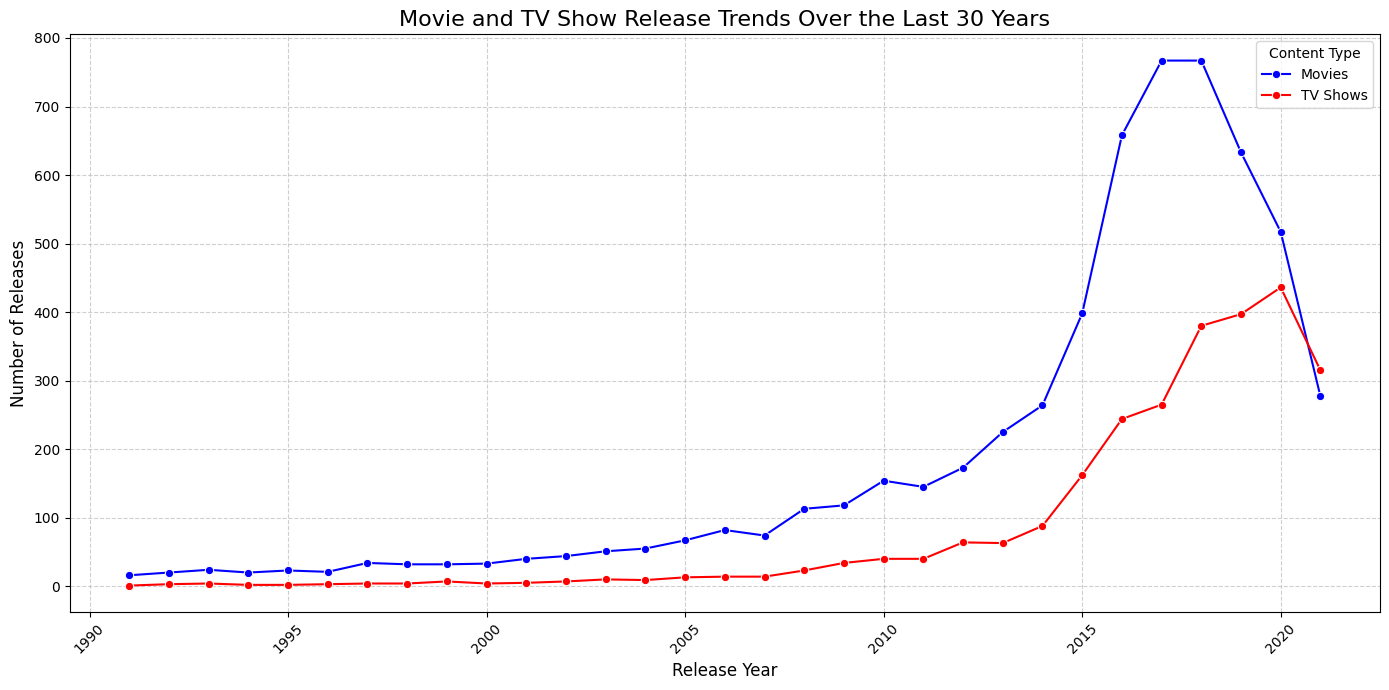

Overlapping line graph showing movie and TV show release trends from 1991 to 2021 has been generated.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of movies released per year (from previous analysis)
movies_per_year = movies_df['release_year'].value_counts().sort_index().reset_index()
movies_per_year.columns = ['release_year', 'count']

# Calculate the number of TV shows released per year (from previous analysis)
tv_shows_df = df[df['type'] == 'TV Show'].copy()
tv_shows_per_year = tv_shows_df['release_year'].value_counts().sort_index().reset_index()
tv_shows_per_year.columns = ['release_year', 'count']

# Determine the time frame (last 30 years from the latest release year in the dataset)
current_year = df['release_year'].max() # Use the overall max release year from df
min_release_year = current_year - 30

# Filter for the recent period for both movies and TV shows
movies_per_year_recent = movies_per_year[movies_per_year['release_year'] >= min_release_year]
tv_shows_per_year_recent = tv_shows_per_year[tv_shows_per_year['release_year'] >= min_release_year]

plt.figure(figsize=(14, 7))
sns.lineplot(x='release_year', y='count', data=movies_per_year_recent, marker='o', label='Movies', color='blue')
sns.lineplot(x='release_year', y='count', data=tv_shows_per_year_recent, marker='o', label='TV Shows', color='red')

plt.title('Movie and TV Show Release Trends Over the Last 30 Years', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Releases', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

print(f"Overlapping line graph showing movie and TV show release trends from {min_release_year} to {current_year} has been generated.")


### Summary of Movie Release Trends

Based on the analysis of the 'Trend of Movie Releases Per Year (Last 30 Years)' line plot and the 'Distribution of Movie Release Years' histogram, the following key trends in movie releases on Netflix are observed:

*   **Overall Upward Trend (Mid-2000s to 2018):** There was a clear and significant upward trajectory in the number of movie releases per year, particularly starting from the mid-2000s. This period indicates an aggressive expansion of Netflix's movie content library.

*   **Peak Years (2017-2018):** Movie releases reached their peak around 2017 and 2018, with both years recording 767 movie releases. This suggests a period of maximum content acquisition and/or production efforts for movies during these years.

*   **Subsequent Decline (2019-2021):** Following the peak, a noticeable decline in movie releases is observed from 2019 onwards. In 2019, releases dropped to 633, further decreasing to 517 in 2020, and sharply to 277 in 2021. This reversal in trend indicates a significant shift in strategy or external factors impacting movie content delivery.

### Summary: TV Show Release Trends

Based on the previous analysis of TV show release trends, the following key findings can be recalled and summarized:

*   **Consistent and Accelerating Growth**: The number of TV shows released per year on Netflix shows a consistent and accelerating upward trend, particularly from the mid-2010s onwards.
*   **Peak in 2020**: The trend reached its peak in 2020, with 436 TV show releases in that year.
*   **Sustained Investment**: A high number of releases was also observed in 2021 (315 releases), indicating sustained and strong investment in TV shows even after the peak.
*   **Divergence from Movie Trends**: This upward trajectory for TV shows stands in stark contrast to movie release trends, which showed a decline post-2018. This suggests a strategic rebalancing of content investment by Netflix.

These trends highlight Netflix's increasing focus on TV shows, likely driven by their effectiveness in subscriber retention, appeal to the binge-watching culture, and potential for global success.

### Comparison

Yes, Netflix appears to have placed a greater focus on TV shows in recent years, particularly from 2019 onwards, as evidenced by the sustained growth and investment in TV shows contrasted with a significant decline in movie releases.

*   **Movie Release Trends:**
    *   Movie releases showed an overall upward trend from the mid-2000s, peaking in 2017 and 2018 with 767 releases each year.
    *   A notable decline began in 2019 (633 releases), further decreasing to 517 in 2020, and sharply to 277 in 2021.
*   **TV Show Release Trends:**
    *   TV shows exhibited a consistent and accelerating upward trend in releases from the mid-2010s.
    *   The peak for TV show releases occurred in 2020 with 436 new releases.
    *   Investment remained strong in 2021, with 315 TV show releases, indicating sustained focus even after the peak year.
*   **Divergence in Trends:** The sustained growth and investment in TV shows, especially post-2018, stands in stark contrast to the sharp decline in movie releases during the same period, suggesting a strategic shift in Netflix's content strategy.

### Insights
*   Netflix has strategically shifted its content focus towards TV shows, likely recognizing their value in subscriber retention and supporting binge-watching culture.



### Content Distribution by Country: Key Insights

Based on the analysis of content types (Movies vs. TV Shows) and their distribution across countries, the following key insights can be recalled:

*   **Top Contributing Countries**: The **United States** is by far the largest content contributor, followed by **India** and the **United Kingdom**. Other significant contributors include Canada, France, Japan, Spain, South Korea, and Germany.

*   **Dominance of Movies Globally, with Regional Nuances**: The overall dataset shows a significantly higher number of Movies compared to TV Shows. This dominance is particularly strong in:
    *   **United States**: Shows a strong preference for Movies (2751) but also has a substantial number of TV Shows (938), indicating a relatively balanced production capacity for both.
    *   **India**: Heavily skewed towards Movies (962) with a comparatively small number of TV Shows (84), suggesting a strong local preference for film content.
    *   **United Kingdom**: More Movies (532) than TV Shows (272), showing a more balanced mix than India, but still movie-dominant.

*   **Emerging TV Show Strongholds**: Countries like **Japan** and **South Korea** exhibit a different pattern, showing a higher or comparable number of TV Shows relative to movies:
    *   **Japan**: More TV Shows (199) than Movies (119).
    *   **South Korea**: Higher proportion of TV Shows (170) compared to Movies (61).
    This indicates a strong preference for serialized content (e.g., anime, K-dramas) in these regions, presenting significant opportunities for Netflix to expand its TV Show catalog there.

*   **'Unknown' Country Content**: A substantial number of entries (831) were categorized as 'Unknown' for country, highlighting content with unspecified origin or complex international co-productions.

###Recommendations

* Increase the financial investment in TV series. TV shows encourage viewers to stay engaged and decrease the likelihood of them canceling their subscriptions, thereby enhancing subscriber retention.

* It's fine to keep movies, but make sure to be selective. Produce fewer films, focusing on those with the potential for significant buzz through awards, star appeal, or compelling narratives, or those that cater effectively to specific audience segments.

* To win on a global scale, focus on local markets. A strong worldwide library is crucial, alongside significant investment in local-language offerings that genuinely appeal to each market.

* Focus more resources on India, Japan, and South Korea. These markets demonstrate a significant demand for particular formats, including Indian films, anime and voice content from Japan, and dramas from Korea. View them as drivers of development.

* Establish local production centers and collaborations. By working in close proximity with local studios, writers, and creators, we can expedite production, refine quality, and optimize expenditures.

* This plan is designed for multiple seasons. Select shows with robust characters and plotlines that can evolve into subsequent seasons, which is key to maintaining long-term viewer commitment.

* Consider short series as a method for fast experimentation. Develop shows with a 1–2 season arc to facilitate rapid experimentation with fresh concepts.

* Make sure your content's duration aligns with viewer behavior. Include a diverse selection of movie lengths, from regular-length films and short children's shows to longer, high-quality productions, so that every viewer can discover content that matches their available time.

* Recommendations should be personalized to match both the time of day and personal preferences. By considering viewing habits like preferred length, genre, and language, we can offer more suitable recommendations, leading to increased watch time and customer satisfaction.

* Focus on improving quality rather than solely increasing quantity. Focus on releasing substantial content during key viewing seasons like mid-year and year-end. Employ data analysis to determine the ideal release times for different regions, aiming to boost views and avoid viewer exhaustion.
